## Feature Extraction and Price Prediction for Mobile Phones

## Load and understand the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\Users\\aakas\\Downloads\\Processed_Flipdata - Processed_Flipdata.csv")

# Display first 5 rows
display(df.head())

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


Dataset Shape: (541, 12)

Column Names:
['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']

Data Types:
Unnamed: 0         int64
Model             object
Colour            object
Memory             int64
RAM                int64
Battery_           int64
Rear Camera       object
Front Camera      object
AI Lens            int64
Mobile Height    float64
Processor_        object
Prize             object
dtype: object

Missing Values:
Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

Duplicate Rows: 0


## Unique-value analysis ✅

In [2]:
# Check unique values and number of unique values
for column in df.columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(f"Number of unique values: {df[column].nunique()}")
    print("Sample unique values:")
    print(df[column].unique()[:20])


Column: Unnamed: 0
Number of unique values: 541
Sample unique values:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Column: Model
Number of unique values: 187
Sample unique values:
['Infinix SMART 7' 'MOTOROLA G32' 'POCO C50' 'Infinix HOT 30i' 'REDMI 10'
 'SAMSUNG Galaxy F13' 'SAMSUNG Galaxy F04' 'POCO C51' 'MOTOROLA e13'
 'vivo T2x 5G' 'Infinix Smart 7 HD' 'REDMI A1+' 'POCO C55' 'MOTOROLA g13'
 'POCO M4 5G' 'MOTOROLA e32' 'vivo T2 5G' 'MOTOROLA G62 5G' 'POCO M5'
 'realme C33 2023']

Column: Colour
Number of unique values: 275
Sample unique values:
['Night Black' 'Azure Blue' 'Mineral Gray' 'Royal Blue' 'Marigold'
 'Glacier Blue' 'Mirror Black' 'Diamond White' 'Shadow Black'
 'Emerald Green' 'Waterfall Blue' 'Opal Green' 'Power Black'
 'Country Green' 'Cosmic Black' 'Aurora Gold' 'Marine Blue'
 'Glimmer Black' 'Green Apple' 'Black']

Column: Memory
Number of unique values: 5
Sample unique values:
[ 64 128  32 256  16]

Column: RAM
Number of unique values: 5
Sample uni

## Step 2: Unique Value Analysis — Observations and Interpretation

### Observations
- The dataset contains 541 records and 12 columns.
- `Model`, `Colour`, and `Processor_` have a high number of unique categories.
- `Memory` and `RAM` contain a limited number of distinct values.
- `Rear Camera` and `Front Camera` contain camera specifications in text format such as MP.
- `AI Lens` is a binary feature with values 0 and 1.
- `Mobile Height` contains some unusually different values that require further investigation.
- `Battery_` also contains some unusually low values that require further investigation.
- `Prize` contains comma-formatted values and is currently stored as an object/text column.

### Interpretation
- High-cardinality features such as `Model`, `Colour`, and `Processor_` will require careful handling during feature encoding.
- `Rear Camera` and `Front Camera` are suitable candidates for numerical feature extraction.
- `Memory`, `RAM`, `Battery_`, `AI Lens`, and `Mobile Height` should be investigated as potential predictors of mobile-phone price.
- The unusual values in `Battery_` and `Mobile Height` should be investigated further during data-quality and outlier analysis before deciding whether they should be removed or treated.
- `Prize` needs to be converted into a numerical format before statistical analysis and machine learning.

## Frequency analysis

In [3]:
# Frequency analysis for important categorical and suspicious columns

columns_to_check = [
    'Model',
    'Colour',
    'Memory',
    'RAM',
    'Battery_',
    'Rear Camera',
    'Front Camera',
    'AI Lens',
    'Mobile Height',
    'Processor_',
    'Prize'
]

for column in columns_to_check:
    print(f"\n{'='*60}")
    print(f"Top values for: {column}")
    print(df[column].value_counts().head(15))


Top values for: Model
Model
vivo Y16                 9
realme C55               9
SAMSUNG Galaxy A14 5G    9
REDMI Note 12 Pro 5G     9
vivo T1 44W              8
Infinix HOT 30i          8
REDMI 10                 8
SAMSUNG Galaxy F14 5G    8
vivo T2x 5G              8
realme C33 2023          6
realme 9i 5G             6
REDMI Note 12            6
REDMI K50i 5G            6
REDMI Note 12 5G         6
REDMI 11 Prime           6
Name: count, dtype: int64

Top values for: Colour
Colour
Yellow            12
Royal Blue         8
Power Black        8
Black              8
Midnight Black     7
Cool Blue          7
Glacier Blue       6
Aqua Blue          6
Force Black        6
Light Green        5
Nebula Blue        5
Carbon Black       5
OMG Black          5
Blue               5
M3)                5
Name: count, dtype: int64

Top values for: Memory
Memory
128    259
64     169
256     55
32      52
16       6
Name: count, dtype: int64

Top values for: RAM
RAM
4    186
8    157
6    121
3   

## Step 3: Frequency Analysis — Observations and Interpretation

### Observations
- The dataset contains 187 unique `Model` values, and the most frequent models occur only 6–9 times.
- `Colour` has 275 unique values, with `Yellow` being the most frequent colour with 12 records.
- `Memory` is dominated by 128 GB (259 records) and 64 GB (169 records).
- `RAM` is mainly distributed among 4 GB (186 records), 8 GB (157 records), and 6 GB (121 records).
- `Battery_` is highly concentrated at 5000 mAh (389 records).
- `Rear Camera` is dominated by 50MP (260 records).
- `Front Camera` is mainly distributed among 16MP, 5MP, and 8MP.
- `AI Lens` is highly imbalanced, with 507 records having value 0 and 34 records having value 1.
- `Mobile Height` is mainly concentrated around 16–17, while some unusual values were observed earlier.
- `Processor_` contains 123 unique processor values, with Qualcomm Snapdragon 680 being the most frequent.
- `Prize` contains 158 unique price values, with ₹15,999 being the most frequent price.

### Interpretation
- `Model`, `Colour`, and `Processor_` are high-cardinality categorical features and will require careful handling during feature encoding.
- `Memory` and `RAM` are promising numerical features for investigating their relationship with mobile-phone price.
- The strong concentration of `Battery_` and `Rear Camera` around a few values should be considered during EDA and feature analysis.
- The `AI Lens` feature is highly imbalanced, so its relationship with price should be investigated carefully.
- `Rear Camera` and `Front Camera` are suitable candidates for numerical feature extraction from their MP specifications.
- The unusual values in `Mobile Height` and `Battery_` require further data-quality and outlier investigation.
- The wide range of `Prize` values makes detailed price-distribution analysis necessary before feature selection and model building.

## Investigate suspicious values

In [4]:
# Investigate unusually low battery values
print("Rows with Battery_ below 2000:")
display(df[df['Battery_'] < 2000])

# Investigate unusual Mobile Height values
print("\nRows with Mobile Height below 10 or above 20:")
display(df[(df['Mobile Height'] < 10) | (df['Mobile Height'] > 20)])

Rows with Battery_ below 2000:


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
98,98,Micromax IN 2C,Nebula Blue,128,6,800,0MP,0MP,0,4.50,SC6531E,"1,449"
108,108,micromax 2,Blade Silver,128,8,1900,2MP,0MP,0,7.11,SC6531E,"1,849"
116,116,micromax,OMG Black,128,4,1000,0MP,0MP,0,4.50,SC6531E,"1,422"
118,118,micromax 1,Eclipse Black,256,8,800,0MP,0MP,0,4.50,SC6531E,"1,299"
133,133,Micromax 3,OMG Black,128,4,1020,2MP,0MP,0,6.10,MediaTek,"2,615"
152,152,micromax 3,Racing Black,64,4,800,2MP,0MP,0,5.08,0 0 0 208MHz,"2,490"
155,155,micromax 2,Nebula Green,256,8,800,0MP,0MP,0,4.50,SC6531E,"1,299"
156,156,micromax 3,Nebula Green,256,4,1020,2MP,0MP,0,6.10,MediaTek,"2,499"
182,182,micromax1,Light Silver,32,3,800,0MP,0MP,0,4.50,SC6531E,"1,599"
193,193,micromax 2,Dark Green,32,4,1020,2MP,0MP,0,6.10,MediaTek,"2,499"



Rows with Mobile Height below 10 or above 20:


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
75,75,MOTOROLA G62 5G,Midnight Gray,128,8,5000,50MP,16MP,0,41.94,Qualcomm Snapdragon 695 5G,"16,499"
88,88,MOTOROLA G62 5G,Frosted Blue,128,8,5000,50MP,16MP,0,41.94,Qualcomm Snapdragon 695 5G,"16,499"
98,98,Micromax IN 2C,Nebula Blue,128,6,800,0MP,0MP,0,4.50,SC6531E,"1,449"
108,108,micromax 2,Blade Silver,128,8,1900,2MP,0MP,0,7.11,SC6531E,"1,849"
116,116,micromax,OMG Black,128,4,1000,0MP,0MP,0,4.50,SC6531E,"1,422"
118,118,micromax 1,Eclipse Black,256,8,800,0MP,0MP,0,4.50,SC6531E,"1,299"
133,133,Micromax 3,OMG Black,128,4,1020,2MP,0MP,0,6.10,MediaTek,"2,615"
152,152,micromax 3,Racing Black,64,4,800,2MP,0MP,0,5.08,0 0 0 208MHz,"2,490"
155,155,micromax 2,Nebula Green,256,8,800,0MP,0MP,0,4.50,SC6531E,"1,299"
156,156,micromax 3,Nebula Green,256,4,1020,2MP,0MP,0,6.10,MediaTek,"2,499"


## Step 4: Investigation of Unusual Values — Observations and Interpretation

### Observations
- Several records contain `Battery_` values below 2000 mAh.
- These low battery values are mainly associated with basic or older phone models and relatively low prices.
- Most `Mobile Height` values are concentrated around 16–17.
- Some `Mobile Height` values are much lower, such as 4.50, 4.57, 5.08, 6.10, and 7.11.
- Two records have a `Mobile Height` value of 41.94.

### Interpretation
- The low `Battery_` values appear to be associated with specific basic or older phone models and should not be removed automatically.
- The unusual `Mobile Height` values may represent different measurement patterns, unit inconsistencies, or data-quality issues and require further investigation.
- At this stage, the unusual values are retained because further statistical and visual analysis is needed before deciding whether any treatment is required.
- The relationship between battery capacity, mobile height, and price will be investigated further during EDA.

## Convert Prize to numerical format

In [5]:
# Convert Prize from text to numerical format

df['Prize'] = df['Prize'].str.replace(',', '').astype(float)

# Check the data type
print("Prize data type:", df['Prize'].dtype)

# Display first 10 prices
print("\nFirst 10 prices:")
print(df['Prize'].head(10))

Prize data type: float64

First 10 prices:
0     7299.0
1     7299.0
2    11999.0
3     5649.0
4     8999.0
5     8999.0
6     8999.0
7     8999.0
8     7999.0
9     7999.0
Name: Prize, dtype: float64


## Interpretation
- Converting `Prize` into numerical format allows us to perform statistical analysis, visualization, correlation analysis, and machine learning.
- `Prize` will be used as the target variable for predicting mobile-phone prices.

## Univariate Analysis 

## Understand the Price 🎯

In [6]:
# Descriptive statistics for Prize

print("Price Statistics:")
print(df['Prize'].describe())

print("\nMedian Price:", df['Prize'].median())

print("Price Skewness:", df['Prize'].skew())

Price Statistics:
count      541.000000
mean     16228.375231
std      10793.588322
min        920.000000
25%       9290.000000
50%      13499.000000
75%      19280.000000
max      80999.000000
Name: Prize, dtype: float64

Median Price: 13499.0
Price Skewness: 2.4255791831830114


## Interpretation
- The difference between the mean and median indicates that higher-priced phones are pulling the average price upward.
- The wide range from ₹920 to ₹80,999 shows substantial variation in mobile-phone prices in the dataset.
- The strong positive skewness suggests that most phones are concentrated at lower or moderate prices, with fewer phones at substantially higher prices.
- The high maximum price should be investigated further during outlier analysis rather than being removed automatically.
- The price distribution should be visualized using a histogram and boxplot to understand its shape and potential outliers more clearly.

## Price Distribution 📊

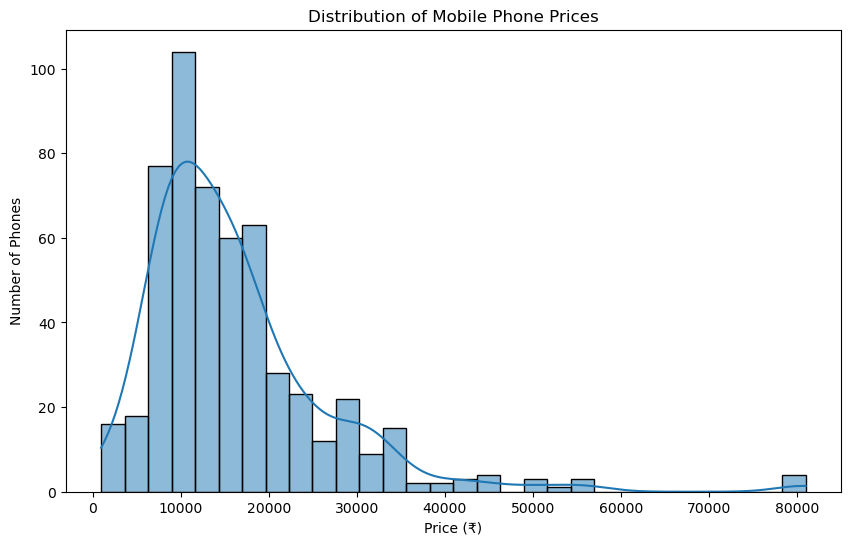

In [7]:
# Price Distribution Histogram

plt.figure(figsize=(10, 6))

sns.histplot(df['Prize'], bins=30, kde=True)

plt.title('Distribution of Mobile Phone Prices')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Phones')

plt.show()

## Interpretation
- The histogram confirms that Prize has a positively/right-skewed distribution, which is consistent with the calculated skewness of approximately 2.43.
- Most phones in the dataset belong to the lower and mid-price ranges, while relatively few phones are premium-priced.
- The high-priced observations should not be removed automatically because they may represent genuine premium mobile phones.
- Further outlier analysis using a boxplot and statistical methods is required before deciding whether any price observations need treatment.

## Price Boxplot

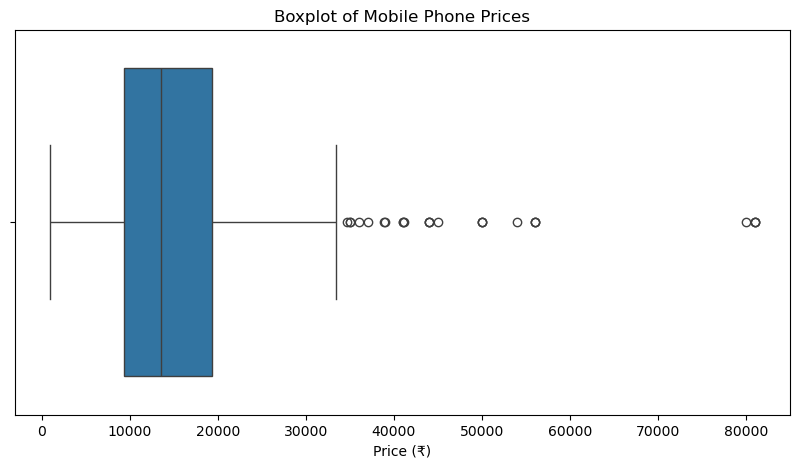

In [8]:
# Price Boxplot

plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Prize'])

plt.title('Boxplot of Mobile Phone Prices')
plt.xlabel('Price (₹)')

plt.show()



### What the boxplot shows

From our earlier statistics:

* Q1 = **₹9,290**
* Median = **₹13,499**
* Q3 = **₹19,280**

So:

**IQR = Q3 − Q1 = ₹19,280 − ₹9,290 = ₹9,990**

Using the standard 1.5 × IQR rule:

**Upper outlier boundary = ₹19,280 + (1.5 × ₹9,990) = ₹34,265**

Therefore, prices above approximately **₹34,265 are statistical outliers according to the IQR method.**


### Observations

* Most prices are concentrated between Q1 (₹9,290) and Q3 (₹19,280).
* Several observations are above the upper outlier boundary of approximately ₹34,265.
* The boxplot shows that the potential outliers are mainly on the higher-price side.

### Interpretation

* The `Prize` variable contains potential high-price outliers, consistent with the right-skewed distribution observed in the histogram.
* These observations should not be removed automatically because they may represent genuine premium or flagship mobile phones.
* The potential outliers should be investigated further before deciding whether any treatment is required.


## Investigate the Price Outliers

In [9]:
# Calculate IQR and upper outlier boundary

Q1 = df['Prize'].quantile(0.25)
Q3 = df['Prize'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify potential high-price outliers
price_outliers = df[df['Prize'] > upper_bound]

print("\nNumber of potential high-price outliers:", len(price_outliers))

display(
    price_outliers[
        ['Model', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
         'Front Camera', 'AI Lens', 'Mobile Height',
         'Processor_', 'Prize']
    ].sort_values('Prize', ascending=False)
)

Q1: 9290.0
Q3: 19280.0
IQR: 9990.0
Lower Bound: -5695.0
Upper Bound: 34265.0

Number of potential high-price outliers: 25


,Model,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
520,APPLE iPhone 14 Plus,128,3,4323,12MP,12MP,0,17.02,6 Core,80999.0
493,APPLE iPhone 14 Plus,128,6,4323,12MP,12MP,0,17.02,IOS,80999.0
525,APPLE iPhone 14 Plus,128,4,4323,12MP,12MP,0,17.02,ios,80999.0
536,SAMSUNG Galaxy S23 5G,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999.0
416,Google Pixel 7,128,8,4270,50MP,8MP,0,16.00,Google Tensor G2,55999.0
426,Google Pixel 7,128,8,4270,50MP,8MP,0,16.00,Google Tensor G2,55999.0
417,Google Pixel 7,128,8,4270,50MP,8MP,0,16.00,Google Tensor G2,55999.0
532,APPLE iPhone 12,64,8,2815,12MP,12MP,0,15.49,ios,53999.0
400,MOTOROLA Edge 30 Ultra,256,4,4610,200MP,60MP,0,16.94,Qualcomm Snapdragon 8+ Gen 1,49999.0
489,MOTOROLA Edge 30 Ultra,256,6,4610,200MP,60MP,0,16.94,Qualcomm Snapdragon 8+ Gen 1,49999.0


## Interpretation 
- The 25 high-price observations appear to represent genuine premium or flagship mobile phones rather than obvious data-entry errors.
- Therefore, these observations will be retained in the dataset.
- Removing these observations could reduce the model's ability to learn pricing patterns for premium mobile phones.
- The outlier analysis indicates that the dataset contains both mainstream and premium-priced phones, which is important for building a realistic price-prediction model.

## Numerical Feature Distribution

In [10]:
# Descriptive statistics for numerical features

numerical_features = [
    'Memory',
    'RAM',
    'Battery_',
    'AI Lens',
    'Mobile Height'
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Memory,541.0,110.550832,60.600694,16.0,64.00,128.00,128.00,256.00
RAM,541.0,5.397412,1.984923,2.0,4.00,6.00,8.00,8.00
Battery_,541.0,4871.587800,780.148862,800.0,5000.00,5000.00,5000.00,7000.00
AI Lens,541.0,0.062847,0.242911,0.0,0.00,0.00,0.00,1.00
Mobile Height,541.0,16.431201,2.523553,4.5,16.51,16.71,16.94,41.94


## Numerical Features Descriptive Statistics — Observations and Interpretation

### Observations

* `Memory` ranges from 16 GB to 256 GB, with a median of 128 GB and the middle 50% of observations between 64 GB and 128 GB.
* `RAM` ranges from 2 GB to 8 GB, with a median of 6 GB.
* `Battery_` ranges from 800 mAh to 7,000 mAh and is highly concentrated around 5,000 mAh.
* `AI Lens` has values from 0 to 1, with a median of 0 and a highly imbalanced distribution.
* `Mobile Height` has a minimum of 4.5 and maximum of 41.94, while the middle 50% of observations are concentrated between 16.51 and 16.94.

### Interpretation

* `Memory` and `RAM` are promising numerical features for investigating their relationship with `Prize`.
* The strong concentration of `Battery_` around 5,000 mAh indicates limited variation for most phones, although some low-capacity observations increase the overall range.
* `AI Lens` is highly imbalanced, so its relationship with `Prize` should be investigated carefully.
* `Mobile Height` contains unusual values compared with its main concentration and requires further investigation during EDA.
* These numerical features will be further analyzed using visualizations and their relationship with `Prize`.


## Visualize Numerical Features 📊

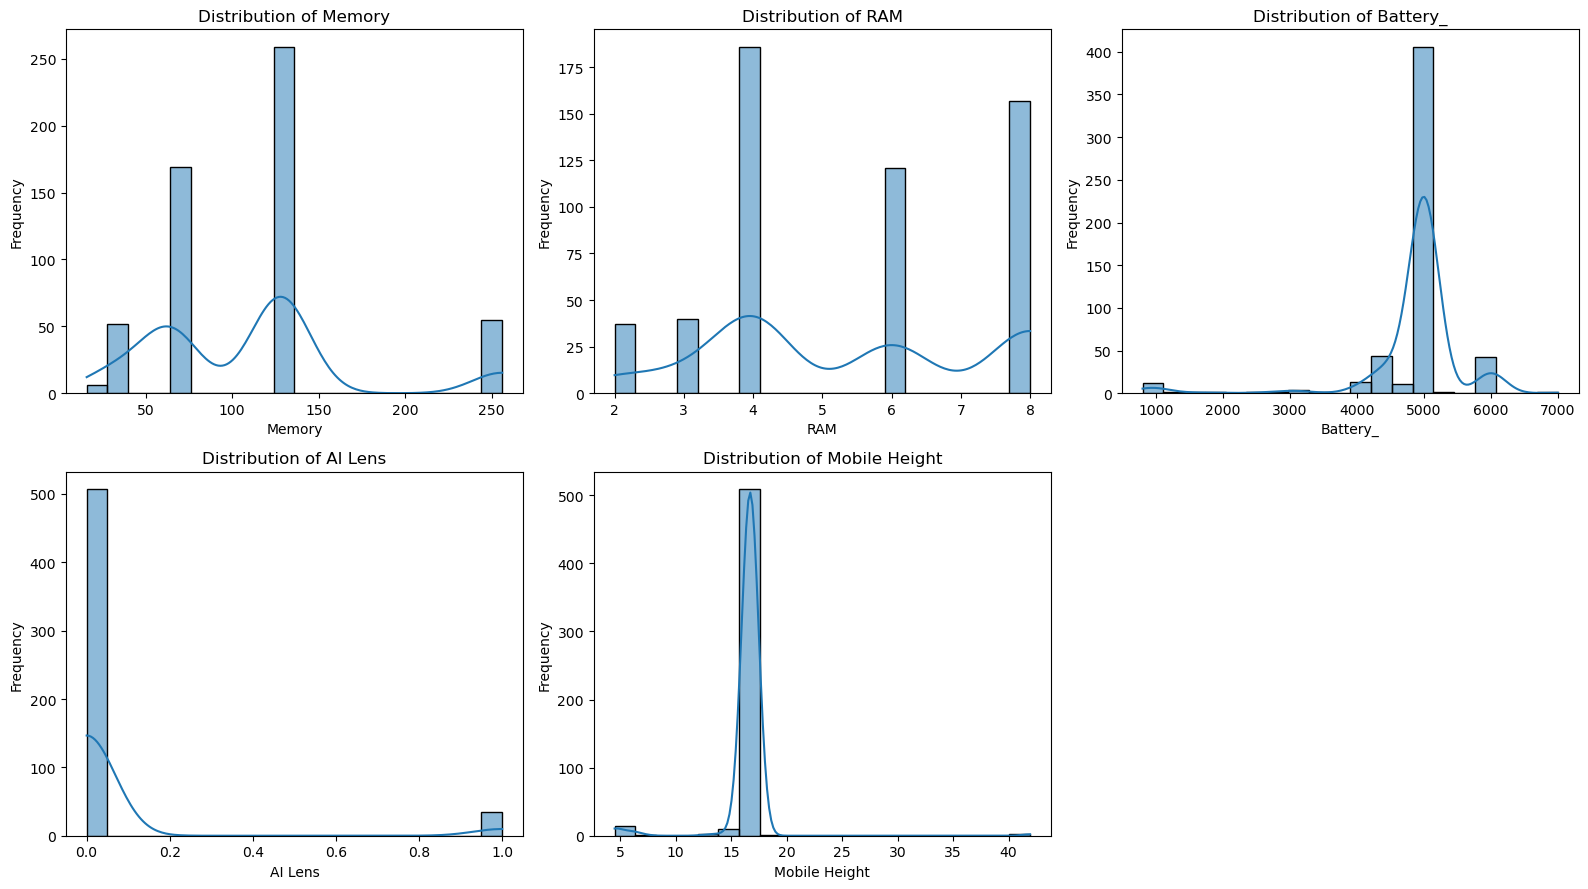

In [11]:
# Distribution of numerical features

numerical_features = [
    'Memory',
    'RAM',
    'Battery_',
    'AI Lens',
    'Mobile Height'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.histplot(df[column], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Remove the unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

##  Numerical Feature Distributions — Observations and Interpretation

### Observations

* `Memory` is mainly concentrated around 64 GB and 128 GB, with 128 GB being the most frequent value.
* `RAM` is mainly distributed across 4 GB, 6 GB, and 8 GB, with 4 GB being the most frequent.
* `Battery_` is strongly concentrated around 5,000 mAh, with smaller groups at other battery capacities.
* `AI Lens` is highly imbalanced, with most observations having a value of 0.
* `Mobile Height` is mainly concentrated around 16–18, with a small number of unusually low values and an extreme high value.

### Interpretation

* `Memory` and `RAM` have discrete distributions and should be investigated further against `Prize` to determine whether higher specifications are associated with higher prices.
* The limited variation in `Battery_` for most phones should be considered when evaluating its predictive usefulness.
* The strong imbalance in `AI Lens` requires comparison of prices between phones with and without the feature.
* The unusual `Mobile Height` values require further investigation before deciding whether any data treatment is necessary.
* The different distributions of the numerical features highlight the need for feature-specific EDA before modelling.


## Bivariate Analysis.
### Numerical VS Numerical

### Memory vs Price

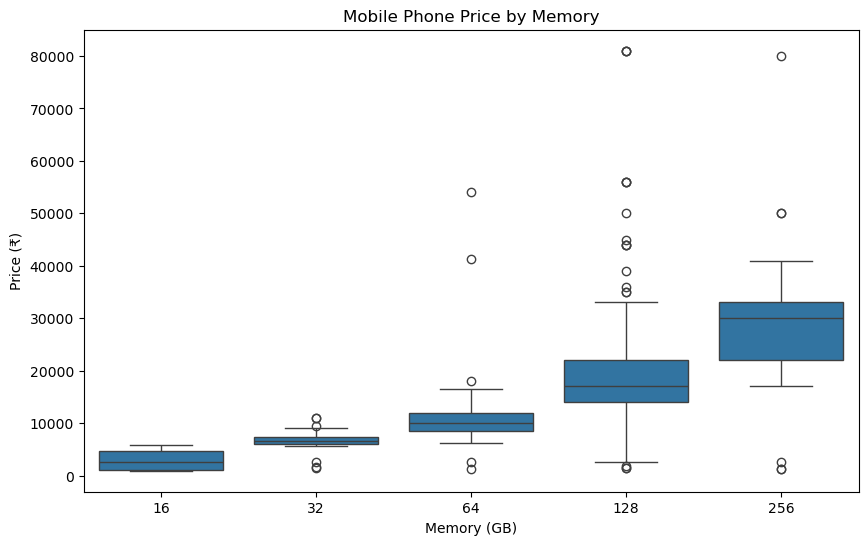

In [12]:
# Memory vs Price

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Memory', y='Prize')

plt.title('Mobile Phone Price by Memory')
plt.xlabel('Memory (GB)')
plt.ylabel('Price (₹)')

plt.show()

## Step 8: Memory vs Price — Observations and Interpretation

### Observations

* The median mobile-phone price increases as `Memory` increases.
* 16 GB phones generally have the lowest price range, while 256 GB phones have the highest typical price range.
* The 128 GB and 256 GB groups contain several high-price observations.
* Potential price outliers are present across multiple memory categories.

### Interpretation

* There is a clear positive association between `Memory` and `Price` in the dataset.
* Higher storage capacity is generally associated with higher mobile-phone prices.
* `Memory` appears to be a potentially important predictor of `Price` and should be retained for further analysis and modelling.
* The relationship is not necessarily causal because other specifications, such as `RAM`, processor, camera, and model, may also contribute to mobile-phone price.


## RAM vs Price

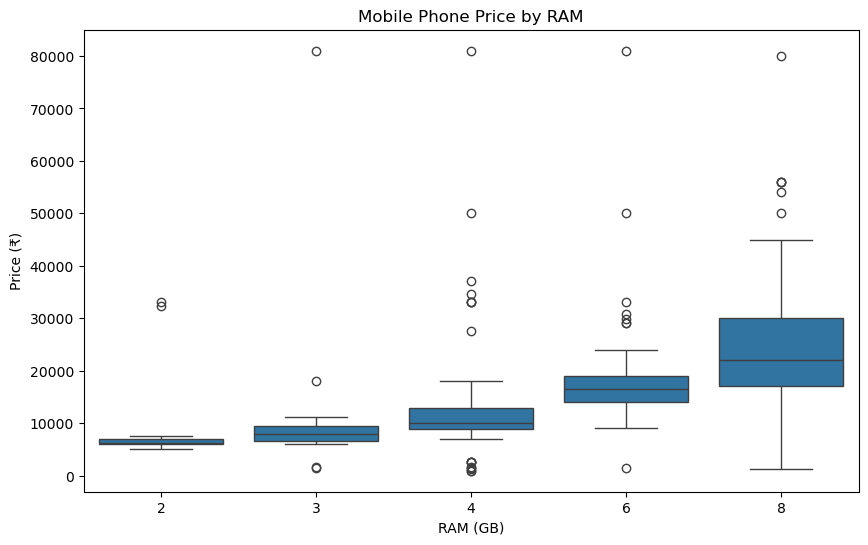

In [13]:
# RAM vs Price

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='RAM', y='Prize')

plt.title('Mobile Phone Price by RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (₹)')

plt.show()

## RAM vs Price — Observations and Interpretation

### Observations

* The median `Price` generally increases as `RAM` increases.
* The 2 GB RAM group has the lowest typical price range.
* The 8 GB RAM group has the highest median price and the widest price range.
* Several high-price observations are present across different RAM categories.
* Some lower-RAM phones also have relatively high prices.

### Interpretation

* There is a positive association between `RAM` and `Price` in the dataset.
* Higher RAM is generally associated with higher mobile-phone prices.
* `RAM` appears to be a potentially important predictor of `Price`.
* However, RAM alone does not determine price, as other features such as `Memory`, processor, camera specifications, and model may also influence price.


## Battery vs Price 🔋

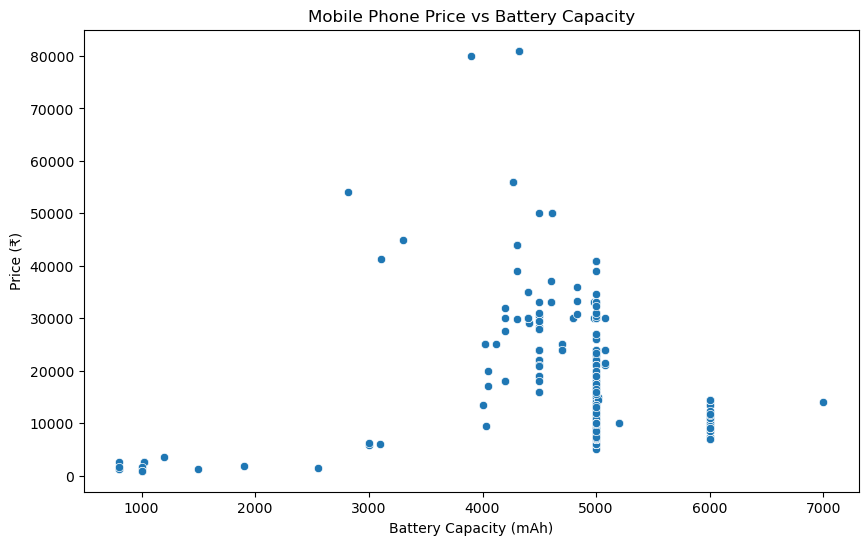

In [14]:
# Battery vs Price

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Battery_', y='Prize')

plt.title('Mobile Phone Price vs Battery Capacity')
plt.xlabel('Battery Capacity (mAh)')
plt.ylabel('Price (₹)')

plt.show()

##  Battery vs Price — Observations and Interpretation

### Observations

* Most mobile phones have battery capacities concentrated around 4,000–5,000 mAh.
* Phones with very low `Battery_` values generally have lower `Price` values.
* Phones with similar battery capacities, particularly around 5,000 mAh, show a wide range of prices.
* Some high-priced phones have battery capacities around 4,000–4,500 mAh rather than the highest battery capacities.

### Interpretation

* `Battery_` shows some association with `Price`, but the relationship does not appear to be strongly linear.
* Battery capacity alone does not explain mobile-phone price differences.
* Other specifications such as `Memory`, `RAM`, processor, camera, and model may contribute more strongly to price.
* `Battery_` will be retained for further analysis and modelling.


## AI Lens vs Price

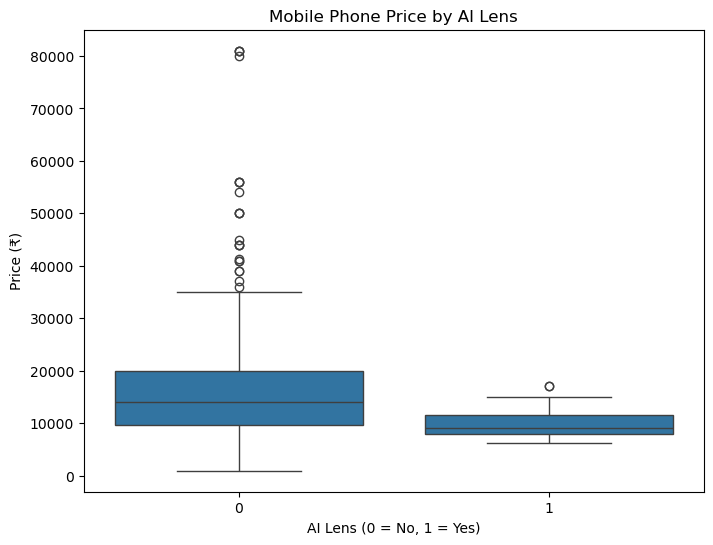

In [15]:
# AI Lens vs Price

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='AI Lens', y='Prize')

plt.title('Mobile Phone Price by AI Lens')
plt.xlabel('AI Lens (0 = No, 1 = Yes)')
plt.ylabel('Price (₹)')

plt.show()

## AI Lens vs Price — Observations and Interpretation

### Observations

* The `AI Lens = 0` group contains substantially more observations than the `AI Lens = 1` group.
* The median `Prize` for phones with `AI Lens = 1` appears lower than the median price for phones with `AI Lens = 0`.
* The `AI Lens = 0` group has a much wider price distribution and contains several high-price observations.
* The `AI Lens = 1` group contains only a small number of observations.

### Interpretation

* In this dataset, phones with `AI Lens = 1` show a lower typical price than phones with `AI Lens = 0`.
* However, this does not mean that having an AI Lens causes a lower price.
* The strong class imbalance and the influence of other phone specifications mean that the usefulness of `AI Lens` should be evaluated together with other features.
* `AI Lens` will be retained for further analysis and modelling at this stage.


## Mobile Height vs Price

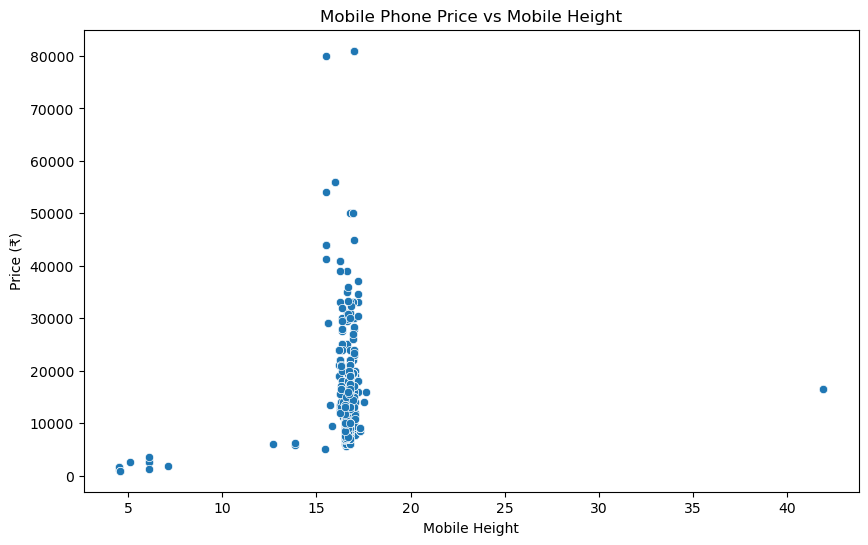

In [16]:
# Mobile Height vs Price

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Mobile Height', y='Prize')

plt.title('Mobile Phone Price vs Mobile Height')
plt.xlabel('Mobile Height')
plt.ylabel('Price (₹)')

plt.show()

## Step 12: Mobile Height vs Price — Observations and Interpretation

### Observations

* Most `Mobile Height` values are concentrated around 15–18.
* Within this main range, mobile-phone prices show substantial variation.
* The unusually low height values around 4.5–7 are generally associated with lower-priced phones.
* The value 41.94 is clearly separated from the main concentration and is associated with a price of approximately ₹16,499.
* No clear strong linear relationship between `Mobile Height` and `Price` is visible from the scatter plot.

### Interpretation

* `Mobile Height` does not appear to have a strong linear relationship with `Price` based on the visual analysis.
* The unusual values should not be removed automatically because further investigation is required to determine whether they represent valid measurements or data-quality issues.
* The extreme value of 41.94 requires particular attention during data-quality and outlier analysis.
* `Mobile Height` will be retained for further analysis until its usefulness and data quality are evaluated more formally.


## Feature Extraction
### Extract Rear Camera Megapixels and  Front Camera Megapixels

In [17]:
# Extract numerical megapixel value from Rear Camera

df['Rear Camera MP'] = (
    df['Rear Camera']
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

print("Rear Camera Feature Extraction:")
print(df[['Rear Camera', 'Rear Camera MP']].head(10))

Rear Camera Feature Extraction:
  Rear Camera  Rear Camera MP
0        13MP            13.0
1        13MP            13.0
2        50MP            50.0
3         8MP             8.0
4        50MP            50.0
5        50MP            50.0
6        50MP            50.0
7        50MP            50.0
8        50MP            50.0
9        50MP            50.0


In [18]:
# Extract numerical megapixel value from Front Camera

df['Front Camera MP'] = (
    df['Front Camera']
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

print("Front Camera Feature Extraction:")
print(df[['Front Camera', 'Front Camera MP']].head(10))

Front Camera Feature Extraction:
  Front Camera  Front Camera MP
0          5MP              5.0
1          5MP              5.0
2         16MP             16.0
3          5MP              5.0
4          5MP              5.0
5          5MP              5.0
6          5MP              5.0
7          5MP              5.0
8          5MP              5.0
9          5MP              5.0


## Interpretation
- The extracted `Rear Camera MP` and `Front Camera MP`feature can now be used for numerical analysis, correlation analysis, feature selection, and machine learning.
-  Keeping the original column preserves the original camera information for reference.

## Camera Features vs Price
### Rear Camera MP vs Price

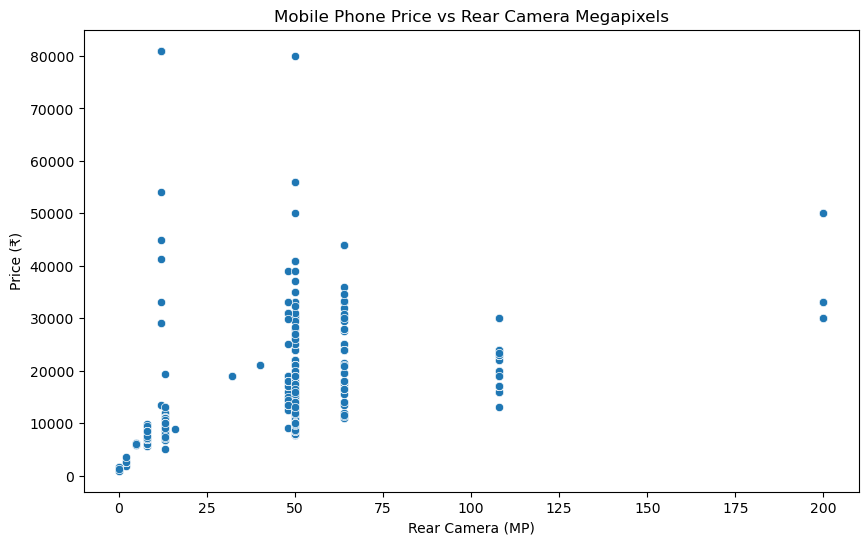

In [19]:
# Rear Camera MP vs Price

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Rear Camera MP', y='Prize')

plt.title('Mobile Phone Price vs Rear Camera Megapixels')
plt.xlabel('Rear Camera (MP)')
plt.ylabel('Price (₹)')

plt.show()

## Rear Camera MP vs Price — Observations and Interpretation

#### Observations

- Phones with very low rear-camera megapixels are generally concentrated in lower price ranges.
- The 13–16 MP and 50–64 MP groups show considerable variation in price.
- Higher camera specifications such as 108 MP and 200 MP are also present in the dataset.
- Phones with similar rear-camera megapixels can have substantially different prices.
- The scatter plot shows considerable variation around the overall upward pattern.

#### Interpretation

- `Rear Camera MP` shows a positive association with `Prize`, particularly when comparing low-camera and higher-camera phones.
- However, the relationship is not perfectly linear, indicating that rear-camera megapixels alone do not determine mobile-phone price.
- Other features such as `Memory`, `RAM`, processor, model, and front camera may also contribute to price differences.
- `Rear Camera MP` will be retained for further correlation analysis, feature selection, and machine learning.

###  Front Camera MP vs Price

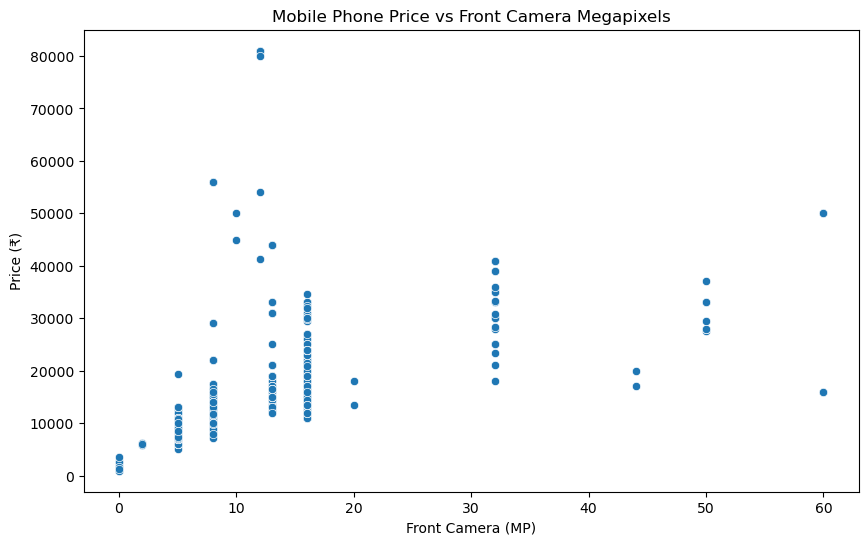

In [20]:
# Front Camera MP vs Price

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Front Camera MP', y='Prize')

plt.title('Mobile Phone Price vs Front Camera Megapixels')
plt.xlabel('Front Camera (MP)')
plt.ylabel('Price (₹)')

plt.show()

## Front Camera MP vs Price — Observations and Interpretation

### Observations

- Phones with very low front-camera megapixels are generally concentrated in lower price ranges.
- The 8–17 MP range contains a large number of observations with substantial price variation.
- Some phones with 12–16 MP front cameras have relatively high prices.
- Higher values such as 32 MP, 50 MP, and 60 MP do not consistently correspond to higher prices.
- Phones with similar front-camera megapixels can have substantially different prices.

### Interpretation

- `Front Camera MP` shows some positive association with `Prize`, particularly when comparing low and moderate camera specifications.
- The relationship does not appear to be strongly linear across all observations.
- Front-camera megapixels alone do not determine mobile-phone price, as other specifications may also influence price.
- `Front Camera MP` will be retained for further correlation analysis, feature selection, and machine learning.

## Categorical vs Numerical
### Processor vs Price

In [21]:
# Top 10 processors by frequency

top_processors = df['Processor_'].value_counts().head(10)

print("Top 10 Processors:")
print(top_processors)

Top 10 Processors:
Processor_
Qualcomm Snapdragon 680       33
Unisoc T612                   21
Mediatek Helio A22            19
Mediatek Dimensity 1080       18
Qualcomm Snapdragon 695 5G    17
Mediatek Helio P35            16
Mediatek Helio G85            10
Mediatek Helio G99            10
Mediatek Dimensity 810 5G     10
Helio G88                     10
Name: count, dtype: int64


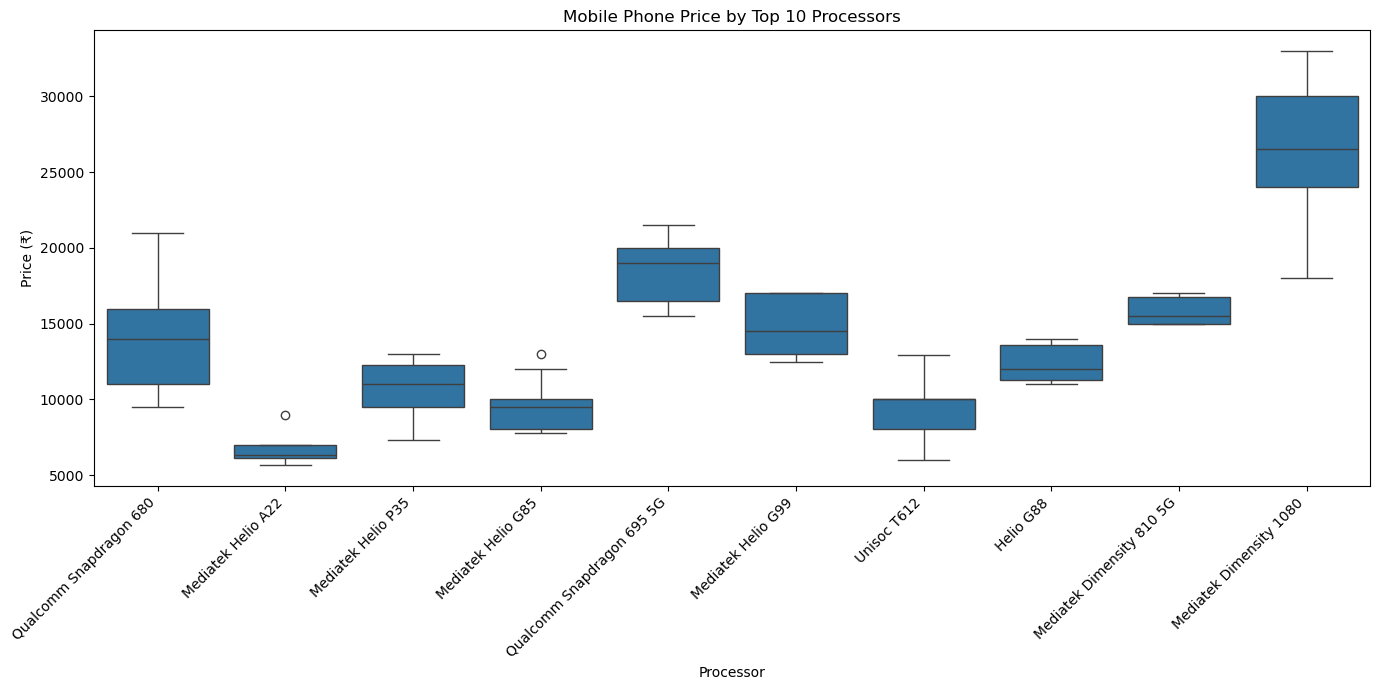

In [22]:
# Select the top 10 most frequent processors

top_processors = df['Processor_'].value_counts().head(10).index

# Filter dataset for top 10 processors
processor_df = df[df['Processor_'].isin(top_processors)]

# Processor vs Price

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=processor_df,
    x='Processor_',
    y='Prize'
)

plt.title('Mobile Phone Price by Top 10 Processors')
plt.xlabel('Processor')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Processor vs Price

### Observations

- The price distribution varies considerably across the top 10 most frequent processor categories.
- MediaTek Dimensity 1080 shows the highest typical price range among the processors displayed.
- MediaTek Helio A22 shows one of the lowest typical price ranges.
- Qualcomm Snapdragon 695 5G and MediaTek Helio G99 also show relatively higher price distributions compared with several other processors.
- Some processor categories show a wider price spread and potential price outliers.
- The analysis represents only the top 10 most frequent processors out of 123 unique processor categories.

### Interpretation

- Processor type shows a noticeable association with mobile-phone price in the dataset.
- Different processor categories are associated with different typical price ranges.
- Processor appears to be a potentially useful predictor of `Price`.
- However, processor type alone does not determine price because other features such as `Memory`, `RAM`, camera specifications, and model may also influence price.
- Further analysis and feature encoding will be required before using `Processor_` in machine learning models.

## Model vs Price

In [23]:
# Top 10 most frequent mobile models

top_models = df['Model'].value_counts().head(10)

print("Top 10 Models:")
print(top_models)

Top 10 Models:
Model
vivo Y16                 9
realme C55               9
SAMSUNG Galaxy A14 5G    9
REDMI Note 12 Pro 5G     9
vivo T1 44W              8
Infinix HOT 30i          8
REDMI 10                 8
SAMSUNG Galaxy F14 5G    8
vivo T2x 5G              8
realme C33 2023          6
Name: count, dtype: int64


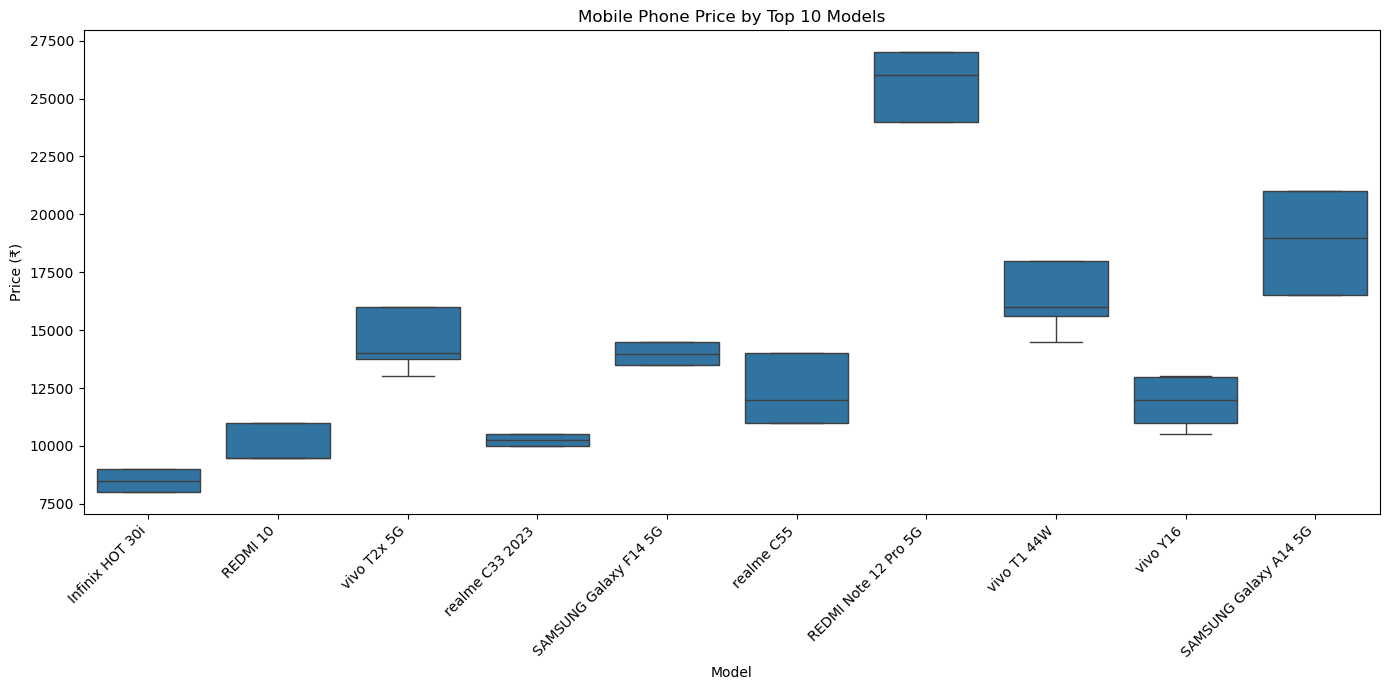

In [24]:
# Select the top 10 most frequent models

top_models = df['Model'].value_counts().head(10).index

# Filter dataset for top 10 models
model_df = df[df['Model'].isin(top_models)]

# Model vs Price

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=model_df,
    x='Model',
    y='Prize'
)

plt.title('Mobile Phone Price by Top 10 Models')
plt.xlabel('Model')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Model vs Price

### Observations

- The price distributions vary considerably across the top 10 most frequent mobile-phone models.
- REDMI Note 12 Pro 5G shows the highest typical price range among the models displayed.
- Infinix HOT 30i shows the lowest typical price range.
- REDMI 10 and realme C33 2023 are also concentrated toward the lower-price range.
- Different models show noticeably different price distributions.
- The analysis includes only the 10 most frequent models out of 187 unique models, with each selected model occurring approximately 8–9 times.

### Interpretation

- Mobile-phone `Model` shows a noticeable association with `Price` in the analyzed records.
- Different models are associated with substantially different typical price ranges.
- `Model` may be an important predictor of `Price`, but its high cardinality requires careful handling during feature encoding.
- The results should not be generalized to all 187 models based only on the top 10 analysis.

## Colour vs Price

In [25]:
# Top 10 most frequent colours

top_colours = df['Colour'].value_counts().head(10).index

print("Top 10 Colours:")
print(df['Colour'].value_counts().head(10))

Top 10 Colours:
Colour
Yellow            12
Royal Blue         8
Power Black        8
Black              8
Midnight Black     7
Cool Blue          7
Glacier Blue       6
Aqua Blue          6
Force Black        6
Light Green        5
Name: count, dtype: int64


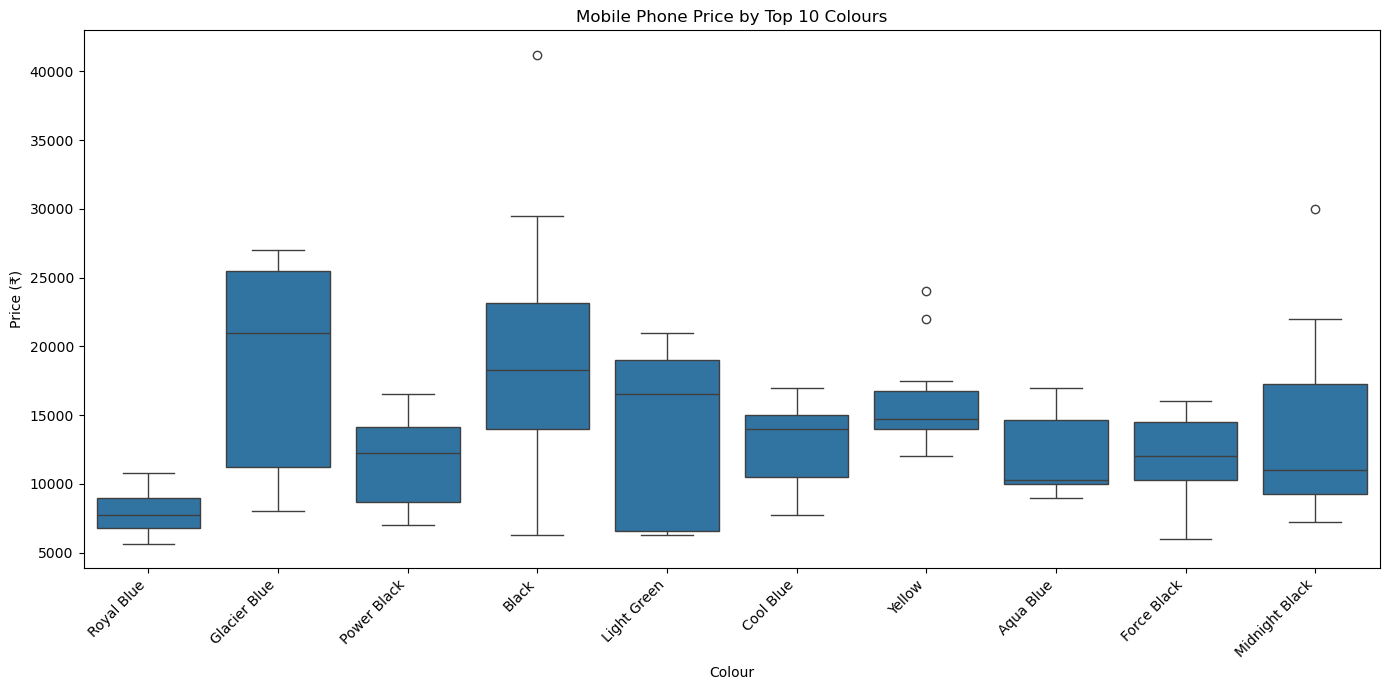

In [26]:
# Select records belonging to the top 10 colours

colour_df = df[df['Colour'].isin(top_colours)]

# Colour vs Price

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=colour_df,
    x='Colour',
    y='Prize'
)

plt.title('Mobile Phone Price by Top 10 Colours')
plt.xlabel('Colour')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Colour vs Price

### Observations

- The price distributions vary across the top 10 most frequent colour categories.
- Glacier Blue and Black show relatively higher median price ranges among the displayed colours.
- Royal Blue shows one of the lower median price ranges.
- Several colour categories have a wide spread of prices.
- Some colour categories contain potential high-price observations.
- The analysis includes only the 10 most frequent colours out of 275 unique colour categories.

### Interpretation

- `Colour` shows some variation in mobile-phone prices across the analyzed categories.
- However, the observed price differences should not be interpreted as a strong direct effect of colour on price.
- Price differences may be influenced by the models and technical specifications associated with particular colours.
- Due to its high cardinality and limited observations for many colour categories, `Colour` should be evaluated carefully during feature selection and modelling.

## Multivariate Analysis — Correlation Metrics

In [27]:
# Select relevant numerical features for correlation analysis

numerical_features = [
    'Memory',
    'RAM',
    'Battery_',
    'AI Lens',
    'Mobile Height',
    'Rear Camera MP',
    'Front Camera MP',
    'Prize'
]

# Calculate Pearson correlation matrix
correlation_matrix = df[numerical_features].corr(method='pearson')

# Display correlation of each feature with Prize
price_correlation = (
    correlation_matrix['Prize']
    .drop('Prize')
    .sort_values(ascending=False)
)

print("Correlation of Numerical Features with Price:")
print(price_correlation)

Correlation of Numerical Features with Price:
Memory             0.566660
Front Camera MP    0.532321
RAM                0.532024
Rear Camera MP     0.410367
Mobile Height      0.176009
Battery_          -0.034297
AI Lens           -0.153691
Name: Prize, dtype: float64


### Correlation Analysis — Observations and Interpretation

#### Observations

- `Memory` has the strongest positive correlation with `Prize` (r = 0.5667).
- `Front Camera MP` (r = 0.5323) and `RAM` (r = 0.5320) also show moderate positive correlations with `Prize`.
- `Rear Camera MP` shows a moderate positive correlation (r = 0.4104).
- `Mobile Height` shows a weak positive correlation with `Prize` (r = 0.1765).
- `Battery_` has a negligible negative correlation with `Prize` (r = -0.0343).
- `AI Lens` shows a weak negative correlation with `Prize` (r = -0.1537).

#### Interpretation

- `Memory`, `Front Camera MP`, `RAM`, and `Rear Camera MP` appear to have the strongest linear associations with mobile-phone price among the numerical features analyzed.
- `Mobile Height` has a relatively weak linear association with price.
- `Battery_` shows almost no linear relationship with price.
- The negative correlation of `AI Lens` should be interpreted cautiously because the feature is highly imbalanced, with relatively few observations having `AI Lens = 1`.
- Correlation measures linear association and does not imply causation.
- Features will not be removed solely on the basis of low correlation; their contribution will also be evaluated through further EDA, feature selection, and machine-learning model performance.

## Correlation Heatmap

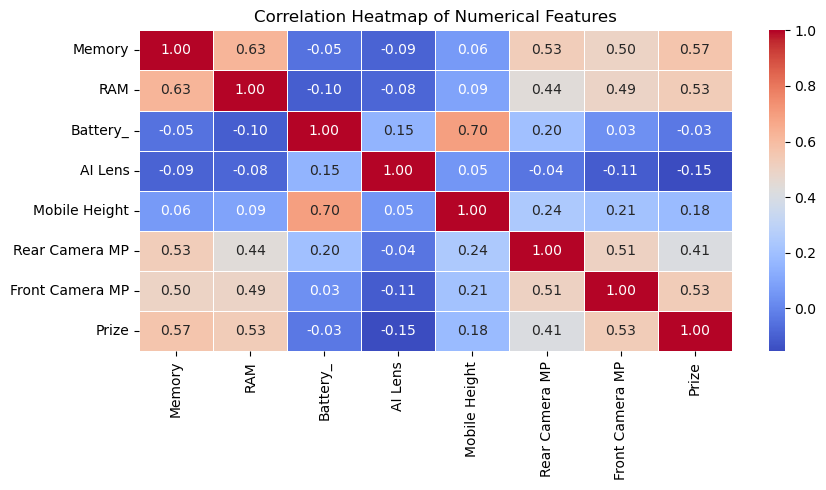

In [28]:
# Correlation heatmap

plt.figure(figsize=(9, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()

plt.show()

## Correlation Heatmap — Observations and Interpretation

### Observations

- `Memory` has the strongest positive correlation with `Price` at approximately 0.57.
- `RAM` and `Front Camera MP` both show moderate positive correlations with `Price` at approximately 0.53.
- `Rear Camera MP` has a moderate positive correlation with `Price` at approximately 0.41.
- `Battery_` and `Mobile Height` have a relatively strong positive correlation of approximately 0.70 with each other.
- `Memory` and `RAM` also show a moderate positive correlation of approximately 0.63.
- `Rear Camera MP` and `Front Camera MP` have a moderate positive correlation of approximately 0.51.
- `Battery_` has almost no linear correlation with `Price`, while `AI Lens` has a weak negative correlation.

### Interpretation

- `Memory`, `RAM`, `Front Camera MP`, and `Rear Camera MP` appear to have the strongest linear associations with mobile-phone price.
- The relatively high correlation between `Battery_` and `Mobile Height` indicates a potential multicollinearity issue that should be investigated further.
- The correlation between `Memory` and `RAM` also suggests some overlap between these predictors.
- Correlation alone is not sufficient to remove features; multicollinearity will be evaluated using VIF before final feature selection.
- The correlation analysis will be considered together with EDA, feature selection, model performance, and feature importance.

##  Multicollinearity Analysis using VIF

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Predictor features for VIF analysis
vif_features = [
    'Memory',
    'RAM',
    'Battery_',
    'AI Lens',
    'Mobile Height',
    'Rear Camera MP',
    'Front Camera MP'
]

# Create dataframe for VIF calculation
X_vif = df[vif_features].copy()

# Add constant/intercept
X_vif = sm.add_constant(X_vif)

# Calculate VIF
vif_data = pd.DataFrame()

vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Remove the constant row
vif_data = vif_data[vif_data['Feature'] != 'const']

# Sort by VIF
vif_data = vif_data.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF):")
print(vif_data)

Variance Inflation Factor (VIF):
           Feature       VIF
3         Battery_  2.186128
5    Mobile Height  2.119023
1           Memory  1.971821
2              RAM  1.853767
6   Rear Camera MP  1.696579
7  Front Camera MP  1.629531
4          AI Lens  1.041008


### Interpretation

- All numerical predictor features have VIF values below 5.
- The VIF results indicate that there is no serious multicollinearity among the numerical predictor features.
- Although some predictor pairs showed moderate correlation in the correlation heatmap, the overall multicollinearity remains within an acceptable range.
- None of the numerical features needs to be removed solely because of multicollinearity.
- The numerical features can therefore be retained for further feature selection and machine-learning modelling.

## Hue-Based Multivariate EDA
### Memory, Price and AI Lens

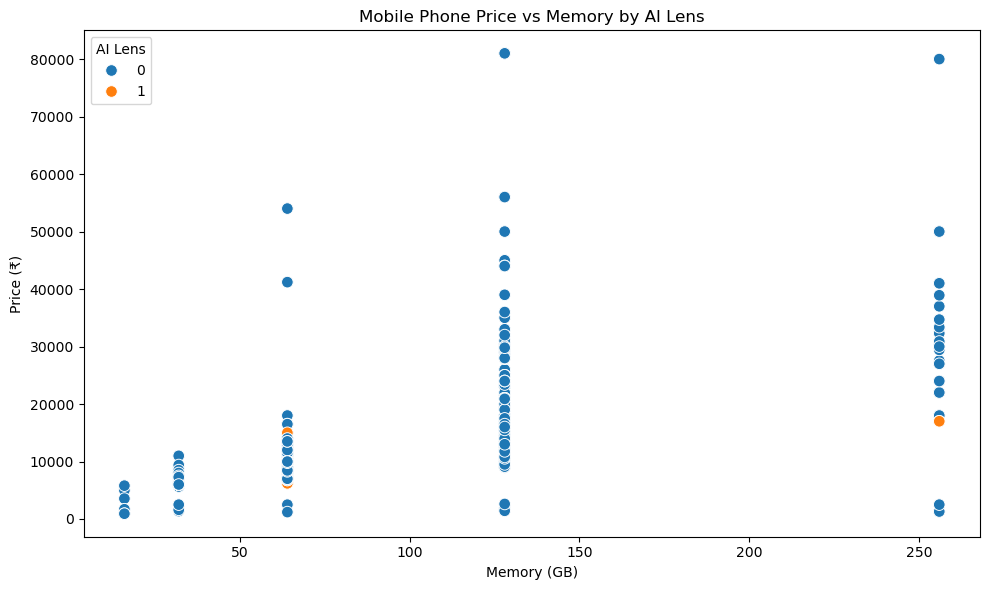

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Memory',
    y='Prize',
    hue='AI Lens',
    s=70
)

plt.title('Mobile Phone Price vs Memory by AI Lens')
plt.xlabel('Memory (GB)')
plt.ylabel('Price (₹)')
plt.legend(title='AI Lens')

plt.tight_layout()
plt.show()

##  Hue-Based Multivariate Analysis — Memory, Price and AI Lens

### Observations

- The overall pattern shows that higher `Memory` categories are generally associated with higher `Prize`.
- Most observations belong to `AI Lens = 0`, while `AI Lens = 1` has relatively few observations.
- The `AI Lens = 1` observations are scattered across different memory levels and do not form a sufficiently large group to establish a separate reliable price pattern.
- Considerable price variation exists even within the same memory category.

### Interpretation

- `Memory` continues to show a clear association with mobile-phone price when observations are viewed according to `AI Lens`.
- The limited number of `AI Lens = 1` observations means that differences between the two AI Lens groups should be interpreted cautiously.
- The visualization provides additional multivariate insight by examining the relationship between memory and price across AI Lens groups.
- `AI Lens` will not be considered an important price determinant based on this visualization alone; its contribution will be evaluated during modelling and feature importance analysis.

#  Feature Selection & Feature Engineering

##  Feature Inventory and Selection Strategy

In [31]:
# Display all columns with their data types and number of unique values

feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

print(feature_summary)

            Feature Data Type  Unique Values
0        Unnamed: 0     int64            541
1             Model    object            187
2            Colour    object            275
3            Memory     int64              5
4               RAM     int64              5
5          Battery_     int64             37
6       Rear Camera    object             14
7      Front Camera    object             13
8           AI Lens     int64              2
9     Mobile Height   float64             38
10       Processor_    object            123
11            Prize   float64            158
12   Rear Camera MP   float64             14
13  Front Camera MP   float64             13


### Removing Unnecessary Columns

In [32]:
# Create a separate dataframe for modelling
model_df = df.copy()

# Remove the unnecessary index column
model_df = model_df.drop(columns=['Unnamed: 0'])

print("Modeling dataset shape:", model_df.shape)

print("\nRemaining columns:")
print(model_df.columns.tolist())

Modeling dataset shape: (541, 13)

Remaining columns:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize', 'Rear Camera MP', 'Front Camera MP']


## Feature Extraction — Removing Raw Camera Columns

In [33]:
# Remove the original text-based camera columns
# because numerical camera megapixel features have already been extracted

model_df = model_df.drop(
    columns=['Rear Camera', 'Front Camera']
)

print("Modeling dataset shape:", model_df.shape)

print("\nFinal columns before preprocessing:")
print(model_df.columns.tolist())

Modeling dataset shape: (541, 11)

Final columns before preprocessing:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize', 'Rear Camera MP', 'Front Camera MP']


## Separating Features and Target

- `X` contains the predictor features used to estimate mobile-phone price.
- `y` contains the target variable, `Prize`.

In [34]:
# Separate predictors and target

X = model_df.drop(columns=['Prize'])
y = model_df['Prize']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (541, 10)
y shape: (541,)

Predictor columns:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Processor_', 'Rear Camera MP', 'Front Camera MP']

Target:
Prize


## Train-Test Split

## Train-Test Split

The dataset is divided into training and testing subsets.

- 80% of the data will be used for model training.
- 20% will be reserved for final model evaluation.
- A fixed random state is used to ensure reproducibility.

In [35]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting set:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Training set:
X_train shape: (432, 10)
y_train shape: (432,)

Testing set:
X_test shape: (109, 10)
y_test shape: (109,)


##  Data Preprocessing — Encoding and Feature Scaling

### Identifying Numerical and Categorical Features

In [36]:
# Define numerical and categorical features

numerical_features = [
    'Memory',
    'RAM',
    'Battery_',
    'AI Lens',
    'Mobile Height',
    'Rear Camera MP',
    'Front Camera MP'
]

categorical_features = [
    'Model',
    'Colour',
    'Processor_'
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Rear Camera MP', 'Front Camera MP']

Categorical features:
['Model', 'Colour', 'Processor_']


## Build the Preprocessing Pipeline
### Encoding and Feature Scaling

Numerical features will be standardized using `StandardScaler`, while categorical features will be converted into numerical form using `OneHotEncoder`.

A `ColumnTransformer` will apply the appropriate preprocessing to each feature type.

In [37]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numerical preprocessing
numeric_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore'
)

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


###  Applying Encoding and Feature Scaling

The preprocessing transformer is fitted only on the training data to prevent data leakage.

The same fitted transformer is then used to transform both the training and testing data.

In [38]:
# Fit preprocessing only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (432, 10)
Processed X_train shape: (432, 540)

Original X_test shape: (109, 10)
Processed X_test shape: (109, 540)


### Verification of Feature Scaling

The numerical features are standardized using `StandardScaler`. The training data should have approximately zero mean and unit standard deviation after scaling.

In [39]:
# Verify scaling on the numerical features

X_train_numeric_scaled = X_train[numerical_features].copy()

scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric_scaled)

scaled_check = pd.DataFrame(
    X_train_numeric_scaled,
    columns=numerical_features
)

print("Mean of scaled numerical features:")
print(scaled_check.mean().round(4))

print("\nStandard deviation of scaled numerical features:")
print(scaled_check.std(ddof=0).round(4))

Mean of scaled numerical features:
Memory             0.0
RAM                0.0
Battery_          -0.0
AI Lens           -0.0
Mobile Height     -0.0
Rear Camera MP     0.0
Front Camera MP   -0.0
dtype: float64

Standard deviation of scaled numerical features:
Memory             1.0
RAM                1.0
Battery_           1.0
AI Lens            1.0
Mobile Height      1.0
Rear Camera MP     1.0
Front Camera MP    1.0
dtype: float64


### Feature Scaling — Observation and Interpretation

#### Observation

- The means of all scaled numerical features are approximately 0.
- The standard deviations of all scaled numerical features are approximately 1.

#### Interpretation

- The results confirm that `StandardScaler` successfully standardized the numerical features in the training data.
- Standardization places numerical features on a comparable scale without changing their underlying relationships.
- This preprocessing is particularly important for scale-sensitive machine-learning algorithms.

## Feature Selection

### Mutual Information Analysis

Mutual Information is used to identify the amount of information each predictor provides about mobile-phone price.

The analysis is performed using the training data only to prevent data leakage.

In [40]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression

# Make a copy of the training predictors
X_train_mi = X_train.copy()

# Temporarily encode categorical features for Mutual Information
ordinal_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_mi[categorical_features] = ordinal_encoder.fit_transform(
    X_train_mi[categorical_features]
)

# Identify categorical columns for Mutual Information
discrete_features = [
    col in categorical_features
    for col in X_train_mi.columns
]

# Calculate Mutual Information
mi_scores = mutual_info_regression(
    X_train_mi,
    y_train,
    discrete_features=discrete_features,
    random_state=42
)

# Create a ranking table
mi_results = pd.DataFrame({
    'Feature': X_train_mi.columns,
    'Mutual Information': mi_scores
})

mi_results = mi_results.sort_values(
    'Mutual Information',
    ascending=False
).reset_index(drop=True)

print("Mutual Information Feature Ranking:")
print(mi_results)

Mutual Information Feature Ranking:
           Feature  Mutual Information
0            Model            2.594272
1       Processor_            1.794285
2           Colour            0.766138
3  Front Camera MP            0.764068
4   Rear Camera MP            0.714787
5           Memory            0.714364
6              RAM            0.709269
7    Mobile Height            0.574182
8         Battery_            0.369800
9          AI Lens            0.069956


#### Interpretation

- `Model` and `Processor_` appear to contain substantial information related to mobile-phone price.
- `Colour` also shows a meaningful dependency with price and should not be removed solely on the basis of its categorical nature.
- `Memory`, `RAM`, `Rear Camera MP`, and `Front Camera MP` are supported as potentially useful predictors by both the EDA and Mutual Information analysis.
- `AI Lens` shows relatively little information about price in this dataset; however, it will not be removed solely on the basis of Mutual Information.
- Mutual Information scores are not percentages and should not be interpreted as direct measures of feature importance.
- Final feature selection will consider Mutual Information together with correlation analysis, EDA, multicollinearity, model performance, and model-based feature importance.

#  Model Building

##  Baseline Regression Models

Multiple regression algorithms are trained and compared to identify the model that provides the best prediction performance for mobile-phone prices.

The preprocessing steps are included within each model pipeline to ensure consistent transformation and prevent data leakage.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Create model pipelines

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

print("All model pipelines created successfully.")

All model pipelines created successfully.


##  Training the Regression Models

In [42]:
# Train all models

linear_model.fit(X_train, y_train)

knn_model.fit(X_train, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## Generating Predictions

In [43]:
# Generate predictions on the test set

y_pred_linear = linear_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test)

y_pred_tree = decision_tree_model.predict(X_test)

y_pred_forest = random_forest_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## Model Evaluation

The models are evaluated using normalized MAE, normalized RMSE, and R² Score.

Normalized MAE and RMSE are calculated by dividing the respective error by the mean actual price in the test set.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

predictions = {
    'Linear Regression': y_pred_linear,
    'KNN Regressor': y_pred_knn,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_forest
}

results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae / np.mean(y_test), 2),
        'RMSE': round(rmse / np.mean(y_test), 2),
        'R² Score': round(r2, 2)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.14,0.41,0.71
1,KNN Regressor,0.17,0.48,0.59
2,Decision Tree,0.08,0.29,0.85
3,Random Forest,0.11,0.29,0.85


### Interpretation

- Decision Tree currently provides the best test-set performance among the four baseline models.
- Random Forest is also a strong-performing model but has slightly higher prediction errors than Decision Tree on this test split.
- KNN performs relatively poorly compared with the other models.
- The final model selection should not be based only on this single test split; cross-validation and feature importance will be examined before making the final decision.

## Cross-Validation

Five-fold cross-validation is used to evaluate the consistency of the regression models.

Each model is trained and evaluated across five different folds of the training data. Mean MAE, RMSE, and R² are calculated to compare the models more reliably.

In [45]:
# Define baseline models for cross-validation

models = {
    'Linear Regression': linear_model,
    'KNN Regressor': knn_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

print("Baseline models defined successfully.")

Baseline models defined successfully.


In [46]:
from sklearn.model_selection import cross_validate
import pandas as pd

cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2'
        },
        n_jobs=1
    )

    # Convert negative scoring values back to positive
    mean_mae = -scores['test_MAE'].mean()
    mean_rmse = -scores['test_RMSE'].mean()
    mean_r2 = scores['test_R2'].mean()

    # Normalize MAE and RMSE using mean training price
    normalized_mae = mean_mae / y_train.mean()
    normalized_rmse = mean_rmse / y_train.mean()

    cv_results.append({
        'Model': model_name,
        'MAE': round(normalized_mae, 2),
        'RMSE': round(normalized_rmse, 2),
        'R² Score': round(mean_r2, 2)
    })

cv_results_df = pd.DataFrame(cv_results)

print("5-Fold Cross-Validation Results:")
display(cv_results_df)

5-Fold Cross-Validation Results:


,Model,MAE,RMSE,R² Score
0,Linear Regression,0.16,0.38,0.61
1,KNN Regressor,0.16,0.33,0.74
2,Decision Tree,0.10,0.24,0.84
3,Random Forest,0.12,0.24,0.86


### Cross-Validation — Observation

- Random Forest achieved the highest mean R² score of 0.86.
- Decision Tree achieved the lowest mean MAE of 0.10.
- Decision Tree and Random Forest both achieved a mean RMSE of 0.24.
- Linear Regression and KNN showed comparatively lower R² scores.
- Overall, Random Forest and Decision Tree demonstrated the strongest cross-validation performance.

## Hyperparameter Tuning

Hyperparameter tuning is performed for the Decision Tree and Random Forest models to identify parameter combinations that may improve prediction performance.

Grid Search with 5-fold cross-validation is applied only to the training data. The test set remains untouched until final model evaluation.

In [47]:
from sklearn.model_selection import GridSearchCV

# Decision Tree hyperparameter grid
dt_param_grid = {
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Grid Search
dt_grid = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=dt_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit using training data only
dt_grid.fit(X_train, y_train)

# Best RMSE from cross-validation
best_dt_rmse = -dt_grid.best_score_

# Normalize RMSE
normalized_dt_rmse = best_dt_rmse / y_train.mean()

# Create result table
tuned_dt_result = pd.DataFrame({
    'Model': ['Tuned Decision Tree'],
    'RMSE': [round(normalized_dt_rmse, 2)]
})

print("Best Decision Tree parameters:")
print(dt_grid.best_params_)

print("\nBest Decision Tree Normalized CV RMSE:")
print(round(normalized_dt_rmse, 2))

print("\nTuned Decision Tree Result:")
display(tuned_dt_result)

Best Decision Tree parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

Best Decision Tree Normalized CV RMSE:
0.22

Tuned Decision Tree Result:


,Model,RMSE
0,Tuned Decision Tree,0.22


In [48]:
from sklearn.model_selection import GridSearchCV

# Random Forest hyperparameter grid
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit using training data only
rf_grid.fit(X_train, y_train)

# Best RMSE from cross-validation
best_rf_rmse = -rf_grid.best_score_

# Normalize RMSE
normalized_rf_rmse = best_rf_rmse / y_train.mean()

# Create result table
tuned_rf_result = pd.DataFrame({
    'Model': ['Tuned Random Forest'],
    'RMSE': [round(normalized_rf_rmse, 2)]
})

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest Normalized CV RMSE:")
print(round(normalized_rf_rmse, 2))

print("\nTuned Random Forest Result:")
display(tuned_rf_result)

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Random Forest Normalized CV RMSE:
0.24

Tuned Random Forest Result:


,Model,RMSE
0,Tuned Random Forest,0.24


## Tuned Model Evaluation

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Get the best tuned models
best_dt_model = dt_grid.best_estimator_
best_rf_model = rf_grid.best_estimator_

# Generate predictions on the untouched test set
y_pred_dt_tuned = best_dt_model.predict(X_test)
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Store predictions
tuned_predictions = {
    'Tuned Decision Tree': y_pred_dt_tuned,
    'Tuned Random Forest': y_pred_rf_tuned
}

tuned_results = []

for name, y_pred in tuned_predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # Normalize using mean actual test price
    normalized_mae = mae / np.mean(y_test)
    normalized_rmse = rmse / np.mean(y_test)

    tuned_results.append({
        'Model': name,
        'MAE': round(normalized_mae, 2),
        'RMSE': round(normalized_rmse, 2),
        'R² Score': round(r2, 2)
    })

tuned_results_df = pd.DataFrame(tuned_results)

print("Tuned Model Evaluation Results:")
display(tuned_results_df)

Tuned Model Evaluation Results:


,Model,MAE,RMSE,R² Score
0,Tuned Decision Tree,0.10,0.26,0.88
1,Tuned Random Forest,0.11,0.29,0.85


## Tuned Models — 5-Fold Cross-Validation

In [50]:
from sklearn.model_selection import cross_validate
import pandas as pd

# Tuned models
tuned_models = {
    'Tuned Decision Tree': dt_grid.best_estimator_,
    'Tuned Random Forest': rf_grid.best_estimator_
}

tuned_cv_results = []

for model_name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2'
        },
        n_jobs=-1
    )

    # Convert negative scores to positive
    mean_mae = -scores['test_MAE'].mean()
    mean_rmse = -scores['test_RMSE'].mean()
    mean_r2 = scores['test_R2'].mean()

    # Normalize using training-set mean price
    normalized_mae = mean_mae / y_train.mean()
    normalized_rmse = mean_rmse / y_train.mean()

    tuned_cv_results.append({
        'Model': model_name,
        'MAE': round(normalized_mae, 2),
        'RMSE': round(normalized_rmse, 2),
        'R² Score': round(mean_r2, 2)
    })

tuned_cv_results_df = pd.DataFrame(tuned_cv_results)

print("Tuned Models — 5-Fold Cross-Validation Results:")
display(tuned_cv_results_df)

Tuned Models — 5-Fold Cross-Validation Results:


,Model,MAE,RMSE,R² Score
0,Tuned Decision Tree,0.11,0.22,0.86
1,Tuned Random Forest,0.12,0.24,0.86


##  Feature Importance Analysis

Feature importance is analyzed using the tuned Decision Tree model to identify which original features contribute most to predicting mobile-phone price.

The one-hot encoded categorical variables are aggregated back to their original feature names for easier interpretation.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the fitted preprocessing pipeline
fitted_preprocessor = best_dt_model.named_steps['preprocessor']

# Get the trained Decision Tree
trained_dt = best_dt_model.named_steps['model']

# Get transformed feature names
transformed_features = fitted_preprocessor.get_feature_names_out()

# Get feature importance values
importance_values = trained_dt.feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Transformed Feature': transformed_features,
    'Importance': importance_values
})

# Map transformed features back to original features
def get_original_feature(feature):
    if feature.startswith('num__'):
        return feature.replace('num__', '')
    
    if feature.startswith('cat__'):
        feature = feature.replace('cat__', '')
        
        for col in categorical_features:
            if feature.startswith(col + '_'):
                return col
    
    return feature

feature_importance_df['Original Feature'] = (
    feature_importance_df['Transformed Feature']
    .apply(get_original_feature)
)

# Aggregate importance by original feature
original_importance = (
    feature_importance_df
    .groupby('Original Feature')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Feature Importance by Original Feature:")
display(original_importance.round(4))

Feature Importance by Original Feature:


,Original Feature,Importance
0,Front Camera MP,0.5200
1,Model,0.2003
2,Battery_,0.0730
3,Memory,0.0674
4,Processor_,0.0469
5,Rear Camera MP,0.0412
6,Mobile Height,0.0232
7,RAM,0.0163
8,Colour,0.0116
9,AI Lens,0.0000


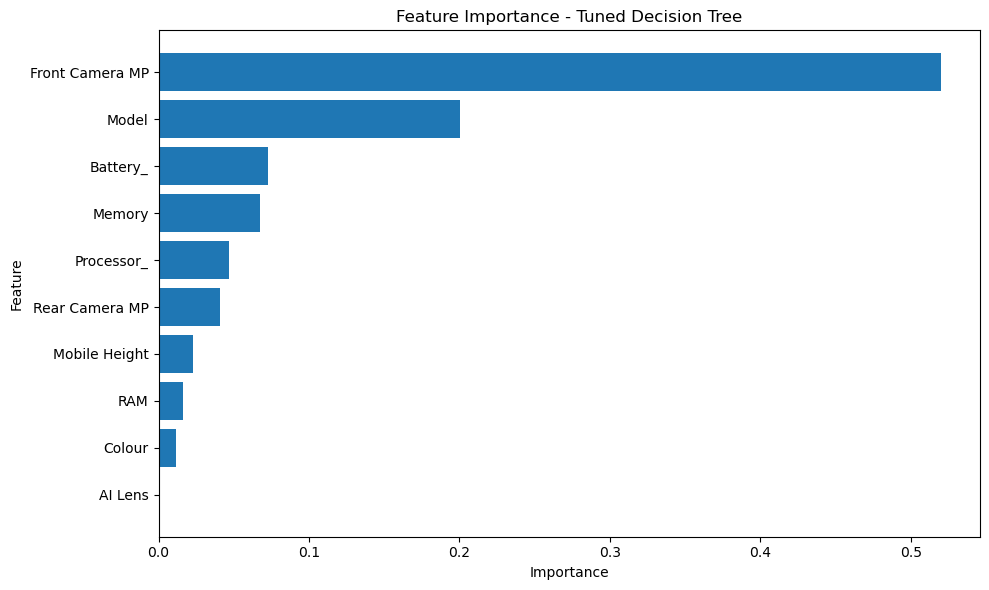

In [52]:
# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    original_importance['Original Feature'],
    original_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Tuned Decision Tree')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance — Observation

- Front Camera MP is the most important feature in the tuned Decision Tree, with an importance of 0.52.
- Model is the second most important feature, with an importance of 0.20.
- Battery capacity and Memory have moderate importance.
- Processor, Rear Camera MP, Mobile Height, RAM, and Colour have relatively lower importance.
- AI Lens has negligible contribution to the model's predictions.
- The feature importance indicates which features the Decision Tree relied on most for prediction; it does not imply that these features directly cause phone prices to increase.

##  Permutation Importance

Permutation importance is used to validate the feature-importance results of the tuned Decision Tree.

It measures how much the model's performance decreases when the values of a feature are randomly shuffled. A larger decrease indicates that the model relied more heavily on that feature for prediction.

In [53]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance on the untouched test set
perm_result = permutation_importance(
    best_dt_model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

# Create dataframe using original predictor columns
permutation_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean
})

# Sort from highest to lowest
permutation_importance_df = (
    permutation_importance_df
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Permutation Importance:")
display(permutation_importance_df.round(4))

Permutation Importance:


,Feature,Importance
0,Front Camera MP,1.0369
1,Battery_,0.1644
2,Rear Camera MP,0.0752
3,Memory,0.0679
4,Processor_,0.0399
5,RAM,0.0268
6,Model,0.0261
7,Mobile Height,0.0254
8,AI Lens,0.0000
9,Colour,-0.0002


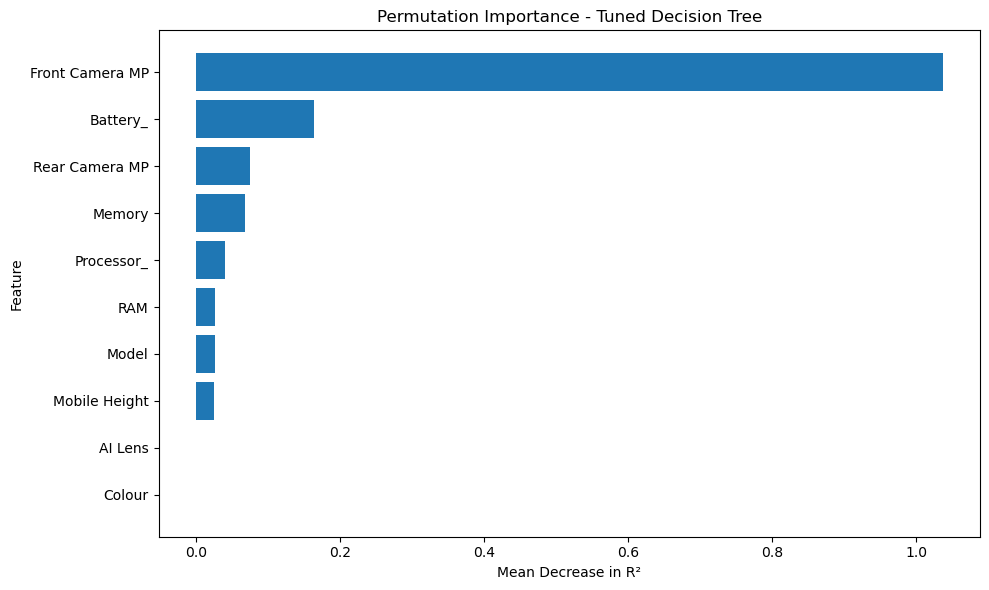

In [54]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_importance_df['Feature'],
    permutation_importance_df['Importance']
)

plt.xlabel('Mean Decrease in R²')
plt.ylabel('Feature')
plt.title('Permutation Importance - Tuned Decision Tree')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Permutation Importance — Observation

- Front Camera MP has the highest permutation importance (1.0369), indicating that the tuned Decision Tree relies strongly on this feature for price prediction.
- Battery capacity is the second most influential feature, followed by Rear Camera MP and Memory.
- Processor, RAM, Model, and Mobile Height have relatively smaller contributions.
- AI Lens has negligible importance, while Colour has almost no contribution in the permutation analysis.
- These results indicate feature importance for the trained model and should not be interpreted as causal relationships.

## Final Model Selection

Based on 5-fold cross-validation and final test-set evaluation, the Tuned Decision Tree is selected as the final model for mobile phone price prediction.

The model achieved a test-set R² score of 0.88 and a normalized MAE of 0.10. Its cross-validation R² score was 0.86, indicating consistent predictive performance across different training-validation splits.

## Actual Price vs Predicted Price

The actual and predicted mobile phone prices are compared to evaluate how closely the final tuned Decision Tree model predicts the true prices.

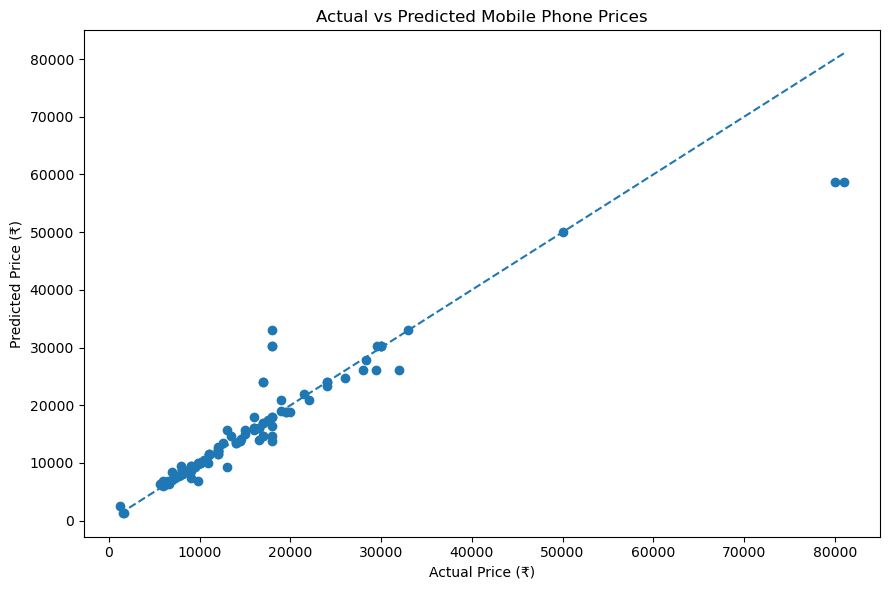

In [55]:
import matplotlib.pyplot as plt

# Predict prices using the final tuned Decision Tree
y_pred_final = best_dt_model.predict(X_test)

# Actual vs Predicted plot
plt.figure(figsize=(9, 6))

plt.scatter(y_test, y_pred_final)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred_final.min())
max_price = max(y_test.max(), y_pred_final.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted Mobile Phone Prices')

plt.tight_layout()
plt.show()

### Actual vs Predicted Price — Observation

- Most predicted prices are reasonably close to the actual prices, indicating good overall model performance.
- The model performs better for low- and mid-priced phones than for some high-priced phones.
- A few observations show noticeable differences between actual and predicted prices.
- The highest-priced phones are substantially underpredicted by the model.
- Overall, the plot supports the good predictive performance indicated by the model's R² score of 0.88.

##  Residual Analysis

Residual analysis is performed to examine the prediction errors of the final tuned Decision Tree model and identify patterns or unusually large errors.

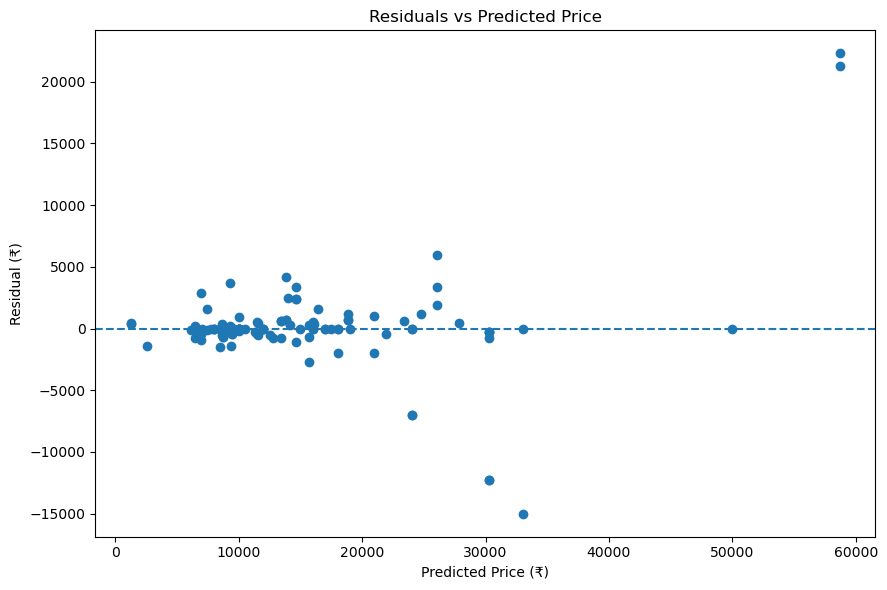

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred_final

# Residuals vs predicted price
plt.figure(figsize=(9, 6))

plt.scatter(y_pred_final, residuals)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price (₹)')
plt.ylabel('Residual (₹)')
plt.title('Residuals vs Predicted Price')

plt.tight_layout()
plt.show()

### Residual Analysis — Observation

- Most residuals are concentrated around zero, indicating reasonably accurate predictions for most observations.
- A few observations show relatively large positive and negative residuals.
- Large positive residuals at higher predicted prices indicate underprediction of some expensive phones.
- Some negative residuals indicate overprediction for certain phones.
- Overall, the residual plot indicates good performance for most observations, with larger errors concentrated in a small number of cases.

## Final Results Summary

In [57]:
final_summary = pd.DataFrame({
    'Metric': [
        'Final Model',
        'Test MAE',
        'Test RMSE',
        'Test R² Score',
        '5-Fold CV MAE',
        '5-Fold CV RMSE',
        '5-Fold CV R² Score'
    ],
    'Result': [
        'Tuned Decision Tree',
        0.10,
        0.26,
        0.88,
        0.11,
        0.22,
        0.86
    ]
})

display(final_summary)

,Metric,Result
0,Final Model,Tuned Decision Tree
1,Test MAE,0.1
2,Test RMSE,0.26
3,Test R² Score,0.88
4,5-Fold CV MAE,0.11
5,5-Fold CV RMSE,0.22
6,5-Fold CV R² Score,0.86


### Final Model

The Tuned Decision Tree was selected as the final model for mobile phone price prediction.

It achieved a test R² Score of 0.88, with a normalized MAE of 0.10 and normalized RMSE of 0.26. Its 5-fold cross-validation R² Score was 0.86, indicating consistent predictive performance across different data splits.

##  Final Findings

### Key Findings

1. Memory showed the strongest Pearson correlation with mobile phone Price (0.57) among the numerical features.
2. Front Camera MP showed the highest feature importance in the tuned Decision Tree (0.5200).
3. Permutation Importance also identified Front Camera MP as the most influential feature for the final model.
4. The Tuned Decision Tree achieved the best overall test performance with an R² Score of 0.88.
5. The final model achieved a normalized MAE of 0.10 and normalized RMSE of 0.26 on the test set.
6. The model performs well for most phones but has difficulty predicting some extreme high-priced phones.

## Business Recommendations

1. Front Camera MP should be considered an important feature when analyzing and positioning mobile phones by price segment, as it was the strongest feature in the final model's importance analysis.

2. Memory should remain an important consideration in pricing analysis because it showed the strongest linear correlation with Price among the numerical features.

3. Battery capacity, Rear Camera MP, Processor, and RAM should also be considered when designing and comparing mobile phone price segments.

4. The organization can use the final Decision Tree model as a supporting tool for estimating the expected price of mobile phones based on their specifications.

5. High-priced phones should be reviewed separately because the model showed larger prediction errors for some extreme-price observations.

6. Pricing decisions should not rely on a single feature. Multiple specifications should be considered together when determining an appropriate price range.

##  Conclusion

This project developed a machine learning solution for predicting mobile phone prices from product specifications. The dataset was explored, cleaned, transformed, and prepared for machine learning. Categorical variables were encoded and numerical features were standardized where required.

Multiple regression models were evaluated using MAE, RMSE, and R² Score. Cross-validation and hyperparameter tuning were then performed to improve model selection.

The Tuned Decision Tree was selected as the final model because it achieved the highest test R² Score of 0.88 and demonstrated strong cross-validation performance with an R² Score of 0.86.

Feature importance and permutation importance identified Front Camera MP as the most influential feature for the final Decision Tree model, while Memory showed the strongest Pearson correlation with Price among the numerical features.

Overall, the developed model provides a useful data-driven approach for estimating mobile phone prices and can support pricing analysis and marketing decisions. However, the model has limitations when predicting some extreme high-priced phones.